In [1]:
import numpy as np
from astropy.io import fits
import os
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import warnings
import matplotlib
from matplotlib import gridspec
plt.style.use('mplstyle')
warnings.simplefilter('ignore', category=UserWarning)

In [2]:
from astropy.io import fits
import numpy as np

def extract_freqs_from_uvfits(uvfits_file):
    """
    Extract observing frequencies (in Hz) from a UVFITS file.
    Works for files with multiple IFs or channels.
    """
    with fits.open(uvfits_file, memmap=True) as hdul:
        header = hdul[0].header
        if 'CRVAL4' in header and 'CDELT4' in header and 'NAXIS4' in header:
            f0 = header['CRVAL4']  # reference frequency (Hz)
            df = header['CDELT4']  # channel width (Hz)
            nchan = header['NAXIS4']
            freqs = f0 + df * np.arange(nchan)
        elif 'FREQ' in header:
            freqs = np.array([header['FREQ']])
        else:
            raise KeyError("No frequency information found in UVFITS header.")
    return freqs


def extract_field_data(uvfits_file, beam_file, freq_hz=147.4e6, zoom_frac=0.2):
    """
    Extract UV coverage in wavelengths and PSF with optional cropping.
    """
    c = 299792458.0  # m/s
    lambda_obs = c / freq_hz  # observing wavelength in meters
    
    # --- UV in meters, then convert to wavelengths ---
    with fits.open(uvfits_file, memmap=True) as hdul:
        data = hdul[0].data
        uu_m = data['UU---SIN'].flatten()  # in meters
        vv_m = data['VV---SIN'].flatten()
    
    uu_lambda = uu_m * freq_hz/1e3 # / lambda_obs  # now in wavelengths
    vv_lambda = vv_m * freq_hz/1e3 # / lambda_obs


    # --- Beam/PSF ---
    with fits.open(beam_file) as hdul:
        beam_data = hdul[0].data.squeeze()  # remove singleton axes
        wcs_full = WCS(hdul[0].header)
    
    # Use only the 2D celestial WCS
    wcs_2d = wcs_full.celestial

    # Optional cropping
    if zoom_frac is not None and zoom_frac < 1.0:
        ny, nx = beam_data.shape
        cy, cx = ny // 2, nx // 2
        dy, dx = max(1, int(ny * zoom_frac / 2)), max(1, int(nx * zoom_frac / 2))
        beam_data = beam_data[cy - dy:cy + dy, cx - dx:cx + dx]

    # print(beam_data.shape)
    field_name = os.path.basename(uvfits_file).split('.')[0]
    return {
        "field": field_name,
        "uu_lambda": uu_lambda,
        "vv_lambda": vv_lambda,
        "beam": beam_data,
        "wcs": wcs_2d
    }


import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from astropy.wcs import WCS

def plot_uv_and_psf(field_data, vmin=None, vmax=None, zoom_frac=0.25, savefile=None):
    """
    Plot UV coverage and PSF with full + zoomed panels using pcolormesh + WCS axes.

    Layout: [UV coverage | Full PSF | Zoomed PSF]
    Colorbar is shared and placed on the rightmost panel.
    zoom_frac: fraction of PSF to display in zoomed panel (0 < zoom_frac <= 1)
    """
    n_fields = len(field_data)
    fig = plt.figure(figsize=(15, 5*n_fields), constrained_layout=True)
    gs = plt.GridSpec(n_fields, 3, width_ratios=[1, 1, 1.1], hspace=-0.1, wspace=0.3)

    ims = []

    for i, (fname, fdata) in enumerate(field_data.items()):
        uu, vv = fdata['uu_lambda'], fdata['vv_lambda']
        beam_full, wcs_full = fdata['beam'], fdata['wcs']
        ny, nx = beam_full.shape
        x_cen, y_cen = nx // 2, ny // 2

        # --- Optional zoomed PSF ---
        dx, dy = int(nx*zoom_frac/2), int(ny*zoom_frac/2)
        beam_zoom = beam_full[y_cen-dy:y_cen+dy, x_cen-dx:x_cen+dx]

        # Shift WCS for zoom
        wcs_zoom = wcs_full.deepcopy()
        wcs_zoom.wcs.crpix[0] -= x_cen - dx
        wcs_zoom.wcs.crpix[1] -= y_cen - dy

        # --- UV coverage subplot ---
        ax_uv = fig.add_subplot(gs[i, 0])
        uv_max = np.max(np.sqrt(uu**2 + vv**2)) # / 1e3  # in kλ, adjust as needed
        # Plot scaled UV tracks
        freqs = extract_freqs_from_uvfits(uvfile)
        f_c = np.mean(freqs)  # central frequency
        for f in freqs:
            scale = f / f_c
            uu_scaled = uu * scale
            vv_scaled = vv * scale
            ax_uv.scatter(uu_scaled, vv_scaled, s=0.5, alpha=0.3, color='black', marker='o', rasterized=True)
            ax_uv.scatter(-uu_scaled, -vv_scaled, s=0.5, alpha=0.15, color='gray', marker='*', rasterized=True)

        # ax_uv.set_ylabel(r"$V\ (k\lambda)$")
        ax_uv.set_xlim(-uv_max, uv_max)
        ax_uv.set_ylim(-uv_max, uv_max)
        ax_uv.set_aspect('equal', adjustable='box')
        ax_uv.set_ylabel(r"$V\ (k\lambda)$", labelpad=-0.1)


        if i == n_fields - 1:
            ax_uv.set_xlabel(r"$U\ (k\lambda)$")
        pc_label = fname[0].upper()
        ax_uv.text(0.95, 0.92, rf"$\rm{{PC\ {pc_label}}}$", color='black', fontsize=12,
                   ha='right', va='top', transform=ax_uv.transAxes,
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='black',
                             linewidth=1.2, boxstyle='round,pad=0.3'))

        # --- Full PSF subplot (middle) ---
        ax_psf_full = fig.add_subplot(gs[i, 1], projection=wcs_full)
        x_edges = np.arange(nx+1)
        y_edges = np.arange(ny+1)
        im_full = ax_psf_full.pcolormesh(x_edges, y_edges, beam_full, cmap='cividis',
                                         shading='auto', vmin=vmin, vmax=vmax, rasterized=True)
        ax_psf_full.set_ylabel(r"$\rm{Dec}$", labelpad=-0.1)
        if i == n_fields - 1:
            ax_psf_full.set_xlabel(r"$\rm{RA}$")
        else:
            ax_psf_full.set_xlabel("")
        ax_psf_full.set_aspect('equal', adjustable='box')

        # Draw rectangle for zoom
        rect = Rectangle((x_cen-dx, y_cen-dy), 2*dx, 2*dy, edgecolor='white', facecolor='none', lw=1, alpha=0.5)
        ax_psf_full.add_patch(rect)

        # --- Zoomed PSF subplot (right) ---
        ax_psf_zoom = fig.add_subplot(gs[i, 2], projection=wcs_zoom)
        nx_zoom, ny_zoom = beam_zoom.shape[1], beam_zoom.shape[0]
        x_zoom = np.arange(nx_zoom+1)
        y_zoom = np.arange(ny_zoom+1)
        im_zoom = ax_psf_zoom.pcolormesh(x_zoom, y_zoom, beam_zoom, cmap='cividis',
                                         shading='auto', vmin=vmin, vmax=vmax, rasterized=True)
        ax_psf_zoom.set_ylabel(r"$\rm{Dec}$", labelpad=-0.1)
        
        if i == n_fields - 1:
            ax_psf_zoom.set_xlabel(r"$\rm{RA}$")
        else:
            ax_psf_zoom.set_xlabel("")
        ax_psf_zoom.set_aspect('equal', adjustable='box')

        
        # if i == n_fields - 1:
        #     ax_psf_zoom.set_xlabel(r"$\rm{RA}$")
        # ax_psf_zoom.set_aspect('equal', adjustable='box')

        ims.append(im_zoom)

                # --- Colorbar for this row only, attached to rightmost panel ---
        cbar = fig.colorbar(im_zoom, ax=ax_psf_zoom, orientation='vertical', fraction=0.046, pad=0.04)
        cbar.locator = matplotlib.ticker.MaxNLocator(nbins=5)
        cbar.update_ticks()
        # cbar.set_label(r"$\rm{Amplitude\ (Jy/beam)}$")

    # # --- Shared colorbar on rightmost panel ---
    # cbar = fig.colorbar(im_zoom, ax=[ax_psf_full, ax_psf_zoom], orientation='vertical', fraction=0.046, pad=0.04)
    # cbar.locator = matplotlib.ticker.MaxNLocator(nbins=5)
    # cbar.update_ticks()
    # cbar.set_label(r"$\rm{Amplitude\ (Jy/beam)}$")

    # fig.tight_layout()
    if savefile:
        plt.savefig(savefile, bbox_inches='tight', dpi=150)
    plt.show()


Loaded 2 fields successfully.


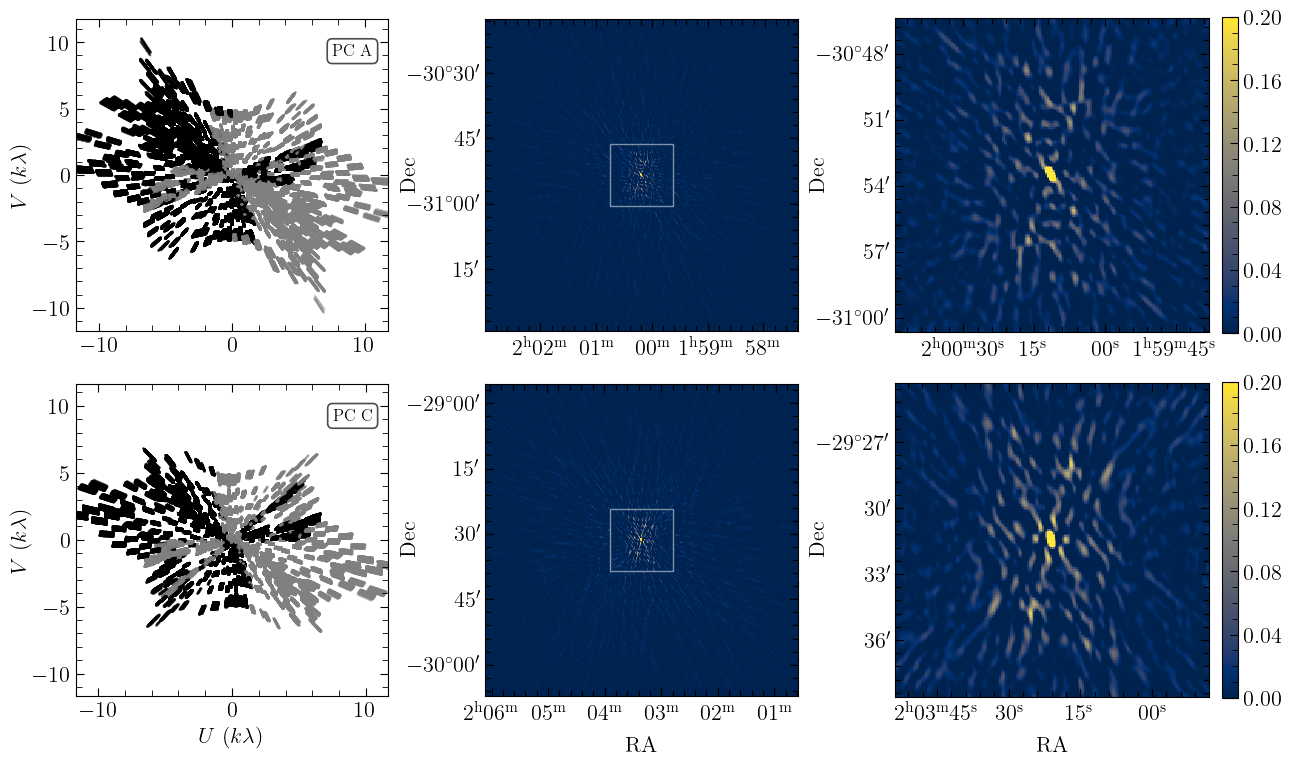

In [3]:
from matplotlib.colors import LogNorm

# --- Main ---
fields = ["AAAA", "CCCC"]
field_data = {}
freq_hz = 147.4e6  # observing frequency

for f in fields:
    uvfile = f"{f}.SP2B.CAL.RR.UVFITS"
    beamfile = f"{f}.SP2B.BEAM.FITS"
    field_data[f] = extract_field_data(uvfile, beamfile, freq_hz=freq_hz, zoom_frac=None)


print(f"Loaded {len(field_data)} fields successfully.")
# Determine common UV limits across all fields
all_uu = np.concatenate([f['uu_lambda'] for f in field_data.values()])
all_vv = np.concatenate([f['vv_lambda'] for f in field_data.values()])
uv_max = np.max(np.abs([all_uu, all_vv])) * 1.05  # small margin



plot_uv_and_psf(field_data, vmin=0.0, vmax=0.2, zoom_frac=0.2, savefile="uvtracksandpsf.pdf")


Loaded 7 fields successfully.


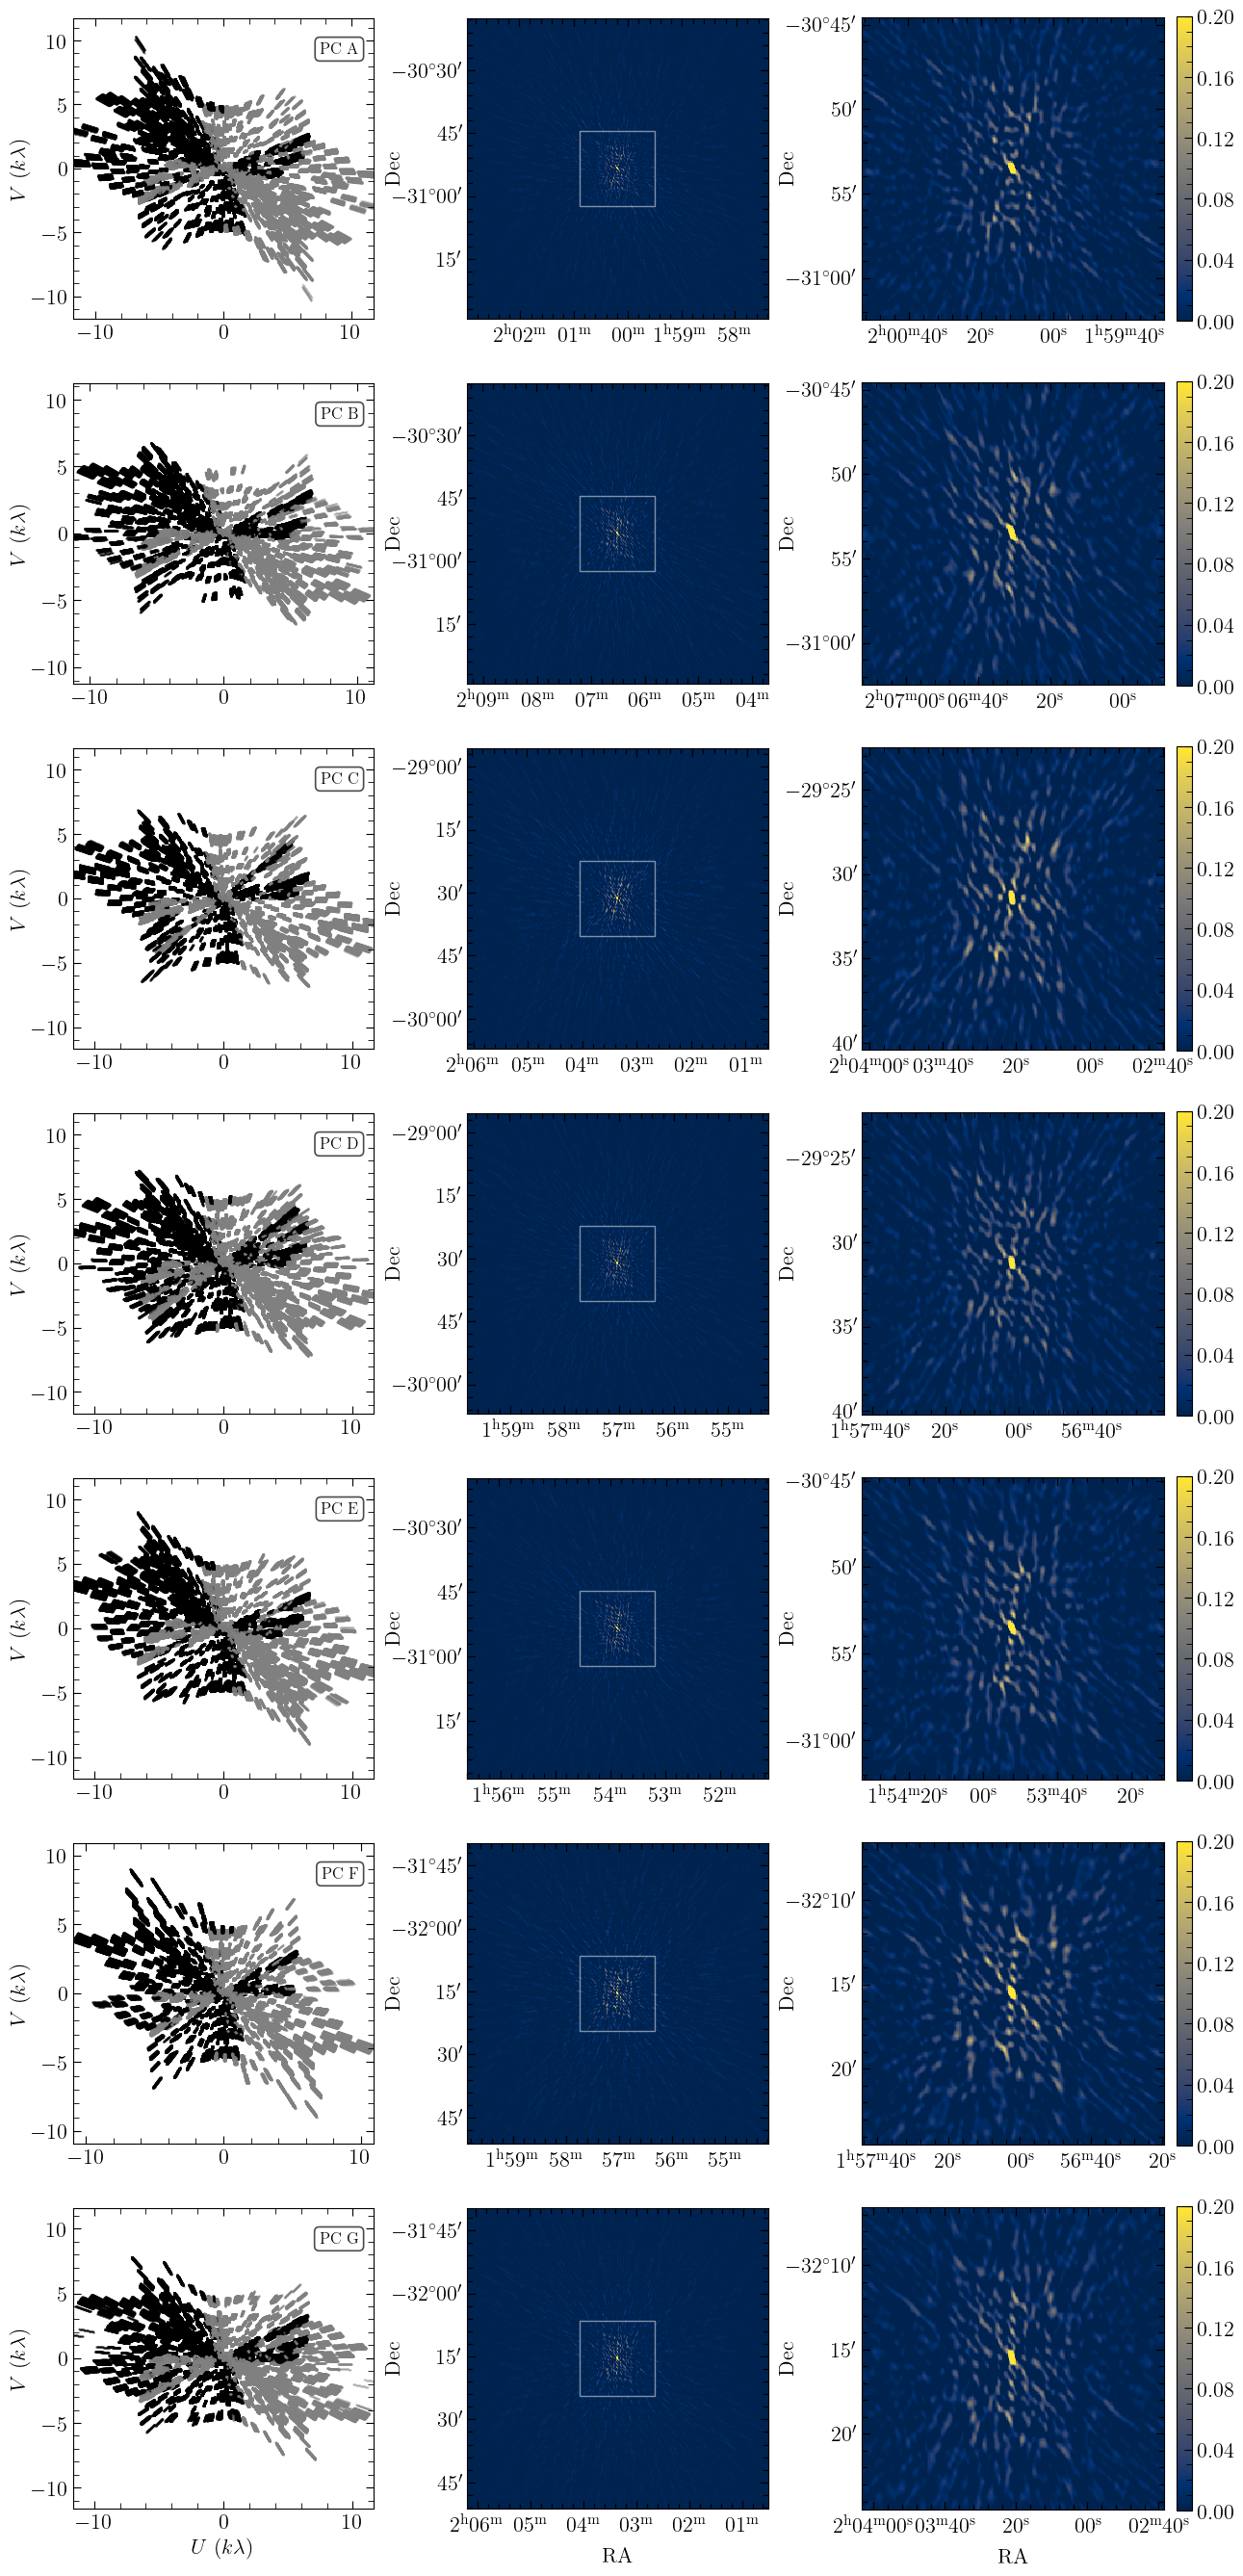

In [4]:

# --- Main ---
fields = ["AAAA", "BBBB", "CCCC", "DDDD", "EEEE", "FFFF", "GGGG"]
field_data = {}
freq_hz = 147.4e6  # observing frequency

for f in fields:
    uvfile = f"{f}.SP2B.CAL.RR.UVFITS"
    beamfile = f"{f}.SP2B.BEAM.FITS"
    field_data[f] = extract_field_data(uvfile, beamfile, freq_hz=freq_hz, zoom_frac=None)

print(f"Loaded {len(field_data)} fields successfully.")



plot_uv_and_psf(field_data, vmin=0., vmax=0.2, zoom_frac=0.25)


In [5]:
field_data

{'AAAA': {'field': 'AAAA',
  'uu_lambda': array([-0.17320927, -0.60911511, -0.1830624 , ..., -0.70993721,
         -1.98288071, -1.27294349]),
  'vv_lambda': array([ 0.0116502 ,  0.11111496, -0.10910385, ...,  1.16086169,
          2.08356694,  0.92270537]),
  'beam': array([[ 0.00644198,  0.00535986,  0.00360611, ...,  0.00535985,
           0.00644198,  0.00693028],
         [ 0.00382065,  0.00218465,  0.00097724, ...,  0.00750489,
           0.00726796,  0.00585016],
         [ 0.00113738, -0.00024763, -0.00067715, ...,  0.00784466,
           0.00627995,  0.00363699],
         ...,
         [ 0.00397395,  0.00623176,  0.00675001, ..., -0.00141388,
          -0.00068841,  0.00124815],
         [ 0.00627995,  0.00784466,  0.00729095, ..., -0.00024763,
           0.00113738,  0.00363699],
         [ 0.00726796,  0.00750489,  0.00603051, ...,  0.00218465,
           0.00382065,  0.00585016]], dtype='>f4'),
  'wcs': WCS Keywords
  
  Number of WCS axes: 2
  CTYPE : 'RA---SIN' 'DEC--SIN'

In [6]:
for i, (fname, fdata) in enumerate(field_data.items()):
    uu, vv = fdata['uu_lambda'], fdata['vv_lambda']
    beam, wcs = fdata['beam'], fdata['wcs']


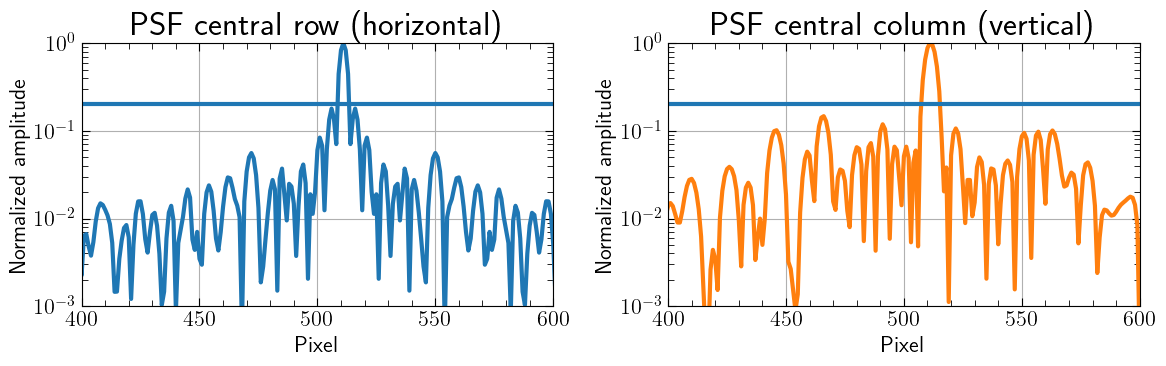

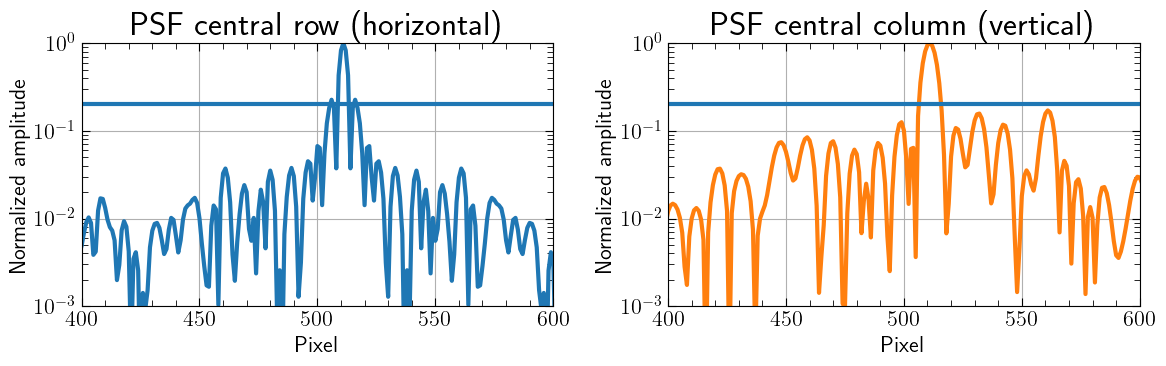

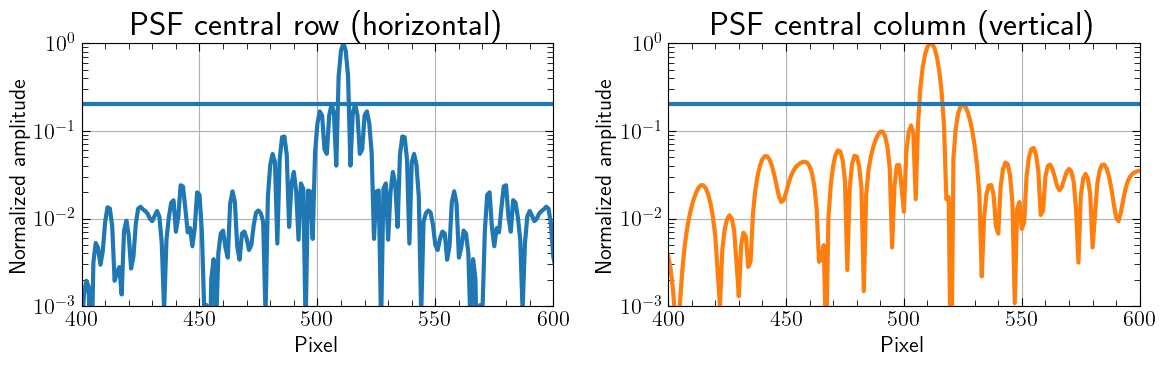

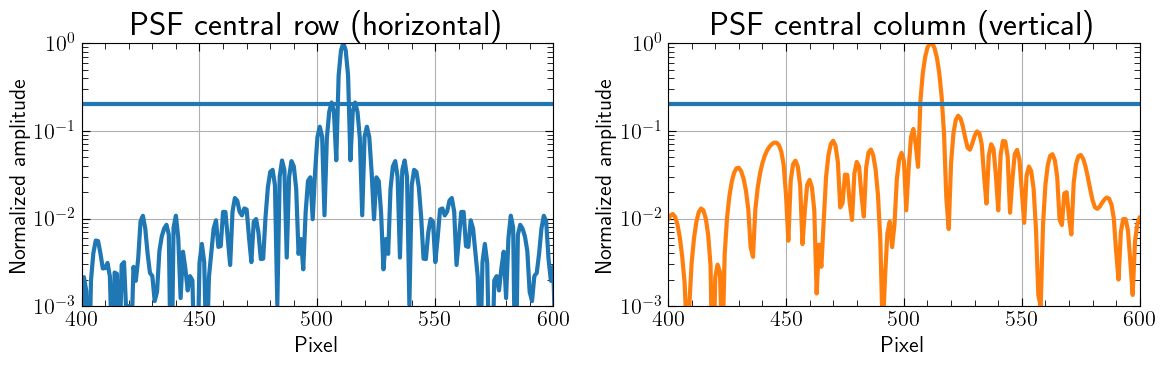

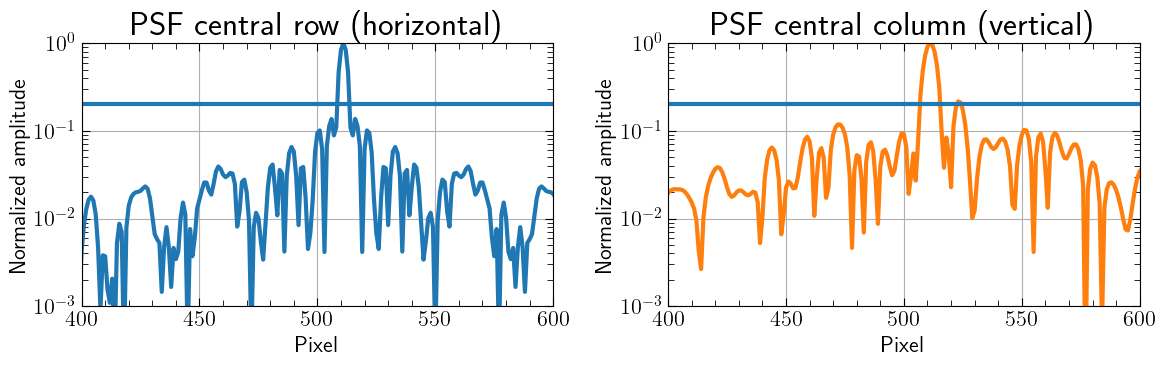

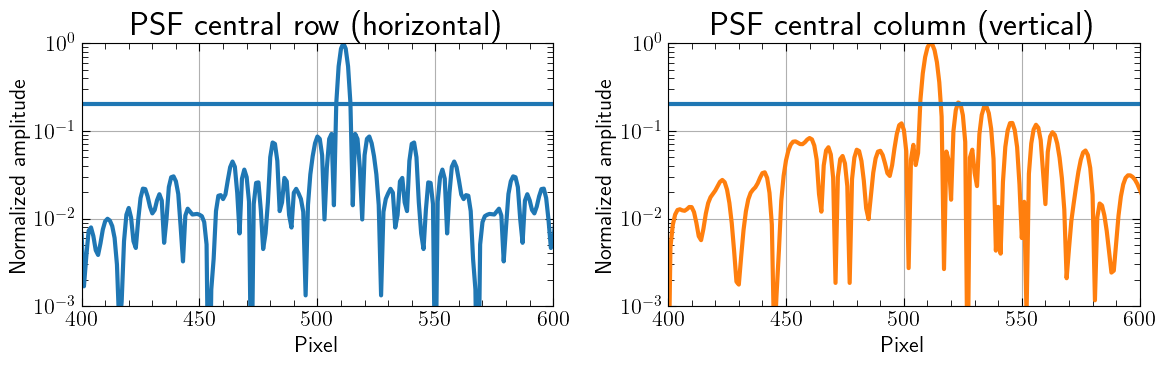

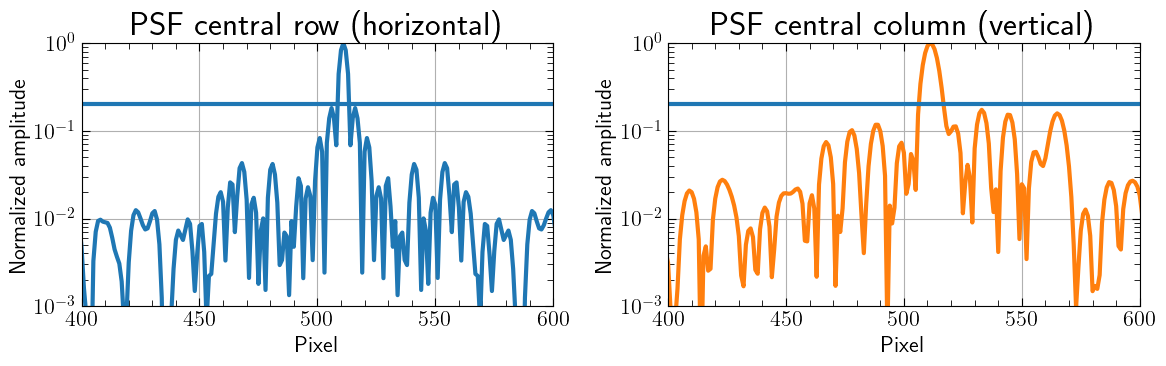

In [7]:
import matplotlib.pyplot as plt
import numpy as np




for i, (fname, fdata) in enumerate(field_data.items()):
    uu, vv = fdata['uu_lambda'], fdata['vv_lambda']
    beam, wcs = fdata['beam'], fdata['wcs']
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    
    
    beam_crop = beam.copy()
    
    ny, nx = beam_crop.shape
    cy, cx = ny // 2, nx // 2  # center coordinates
    
    # Central slices
    psf_x = beam_crop[cy, :]  # horizontal cut
    psf_y = beam_crop[:, cx]  # vertical cut
    
    x = np.arange(nx)
    y = np.arange(ny)
    
    
    
    # Horizontal cut
    ax[0].plot(x, abs(psf_x / np.max(psf_x)), color='C0')
    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel("Normalized amplitude")
    ax[0].set_title("PSF central row (horizontal)")
    ax[0].grid(True)
    ax[0].set_yscale('log')
    ax[0].axhline(0.2)
    ax[0].set_xlim(400, 600)
    ax[0].set_ylim(1e-3, 1)

    # Vertical cut
    ax[1].plot(y, abs(psf_y / np.max(psf_y)), color='C1')
    ax[1].set_xlabel("Pixel")
    ax[1].set_ylabel("Normalized amplitude")
    ax[1].set_title("PSF central column (vertical)")
    ax[1].grid(True)
    ax[1].set_yscale('log')
    ax[1].axhline(0.2)
    ax[1].set_xlim(400, 600)
    ax[1].set_ylim(1e-3, 1)
    
    plt.tight_layout()
    
    plt.show()
